# SBSAT_STD Results Analysis

This notebook analyses the final results for the SBSAT_STD project.

The task is to predict subjective text difficulty using text and eye-tracking data. The task is regression.

The main metrics are:

* RMSE
* MAE
* R²

The main custom model is `RoberteyeResidualGated`.

This notebook does not train models. It only loads saved results and explains them.


## 1. Setup

This section imports the required packages and defines the project paths.

The notebook is stored in project_report_analysis/.

It reads the final results from the main project folders.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

current_dir = Path.cwd().resolve()

if current_dir.name == "project_report_analysis":
    project_dir = current_dir.parent
    utils_dir = current_dir
else:
    project_dir = current_dir
    utils_dir = project_dir / "project_report_analysis"

if str(utils_dir) not in sys.path:
    sys.path.insert(0, str(utils_dir))

import report_utils as ru  # noqa: E402

results_dir = project_dir / "results" / "eyebench_benchmark_results"
outputs_dir = project_dir / "outputs"

project_dir, results_dir, outputs_dir

(PosixPath('/workspaces/eyebench-project/sbsat_report_analysis'),
 PosixPath('/workspaces/eyebench-project/sbsat_report_analysis/results/eyebench_benchmark_results'),
 PosixPath('/workspaces/eyebench-project/sbsat_report_analysis/outputs'))

## 2. Load result files

The files contain RMSE, MAE, and R² values for the baseline models and the custom models.

In [2]:
rmse_path = results_dir / "rmse_with_RoberteyeResidualGated_and_Huber.csv"
mae_path = results_dir / "mae_with_RoberteyeResidualGated_and_Huber.csv"
r2_path = results_dir / "r2_with_RoberteyeResidualGated_and_Huber.csv"

In [3]:
rmse = pd.read_csv(rmse_path)
mae = pd.read_csv(mae_path)
r2 = pd.read_csv(r2_path)

rmse.shape, mae.shape, r2.shape

((16, 7), (16, 7), (16, 7))


`Roberta` is the text-only baseline. It uses only the paragraph text.

`RoberteyeLate` is the multimodal late-fusion baseline. It combines text features and eye-tracking features before the final prediction.

`RoberteyeResidualGated` is the main custom model. It starts from a text-based prediction and adds a gaze-based residual correction.

`RoberteyeResidualGatedHuber` uses the same architecture as RoberteyeResidualGated, but it is trained with Huber loss instead of mean squared error.

## 3. Models compared

`Roberta` is the text-only baseline. It uses only the paragraph text.

`RoberteyeLate` is the multimodal late-fusion baseline. It combines text features and eye-tracking features before the final prediction.

`RoberteyeResidualGated` is the main custom model. It starts from a text-based prediction and adds a gaze-based residual correction.

`RoberteyeResidualGatedHuber` uses the same architecture as RoberteyeResidualGated, but it is trained with Huber loss instead of mean squared error.

We also tested two exploratory size variants of the custom model: RoberteyeResidualGatedSmall and RoberteyeResidualGatedMedium.

These variants used the same residual-gated idea, but reduced the capacity of the custom gaze-fusion component.

The motivation was to check whether a smaller model would generalize better and avoid overfitting to noisy gaze features.

These variants did not improve validation performance compared with the main RoberteyeResidualGated model.

Therefore, they were not included in the final model comparison.


## 4. Main model comparison

This section compares the main models on the test set.

For RMSE and MAE, lower values are better.

For R², higher values are better.

In [4]:
models = [
    "Roberta",
    "RoberteyeLate",
    "RoberteyeResidualGated",
    "RoberteyeResidualGatedHuber",
]

In [5]:
main_results = ru.get_metric_table(rmse, "RMSE", models)
main_results = main_results.merge(ru.get_metric_table(mae, "MAE", models), on="Model")
main_results = main_results.merge(ru.get_metric_table(r2, "R2", models), on="Model")

main_results

,Model,RMSE,MAE,R2
0,Roberta,0.72 ± 0.0,0.58 ± 0.0,-0.07 ± 0.0
1,RoberteyeLate,0.75 ± 0.0,0.58 ± 0.0,-0.16 ± 0.1
2,RoberteyeResidualGated,0.72 ± 0.03,0.57 ± 0.04,-0.08 ± 0.05
3,RoberteyeResidualGatedHuber,0.73 ± 0.04,0.57 ± 0.04,-0.10 ± 0.08


In [6]:
metric_plot = ru.add_metric_columns(
    main_results,
    metrics=["RMSE", "MAE", "R2"],
)

metric_plot[["Model", "RMSE_mean", "MAE_mean", "R2_mean"]]

,Model,RMSE_mean,MAE_mean,R2_mean
0,Roberta,0.72,0.58,-0.07
1,RoberteyeLate,0.75,0.58,-0.16
2,RoberteyeResidualGated,0.72,0.57,-0.08
3,RoberteyeResidualGatedHuber,0.73,0.57,-0.10


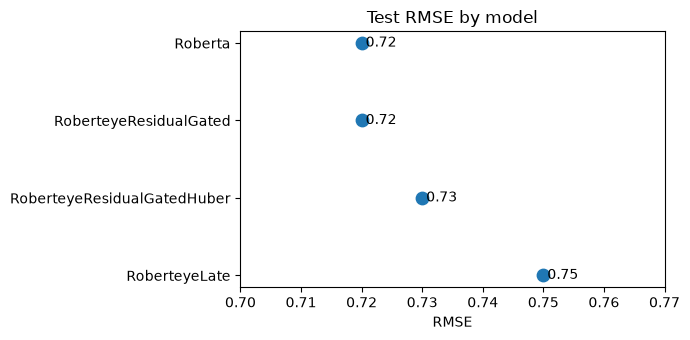

In [7]:
ru.plot_metric_points(metric_plot, "RMSE")

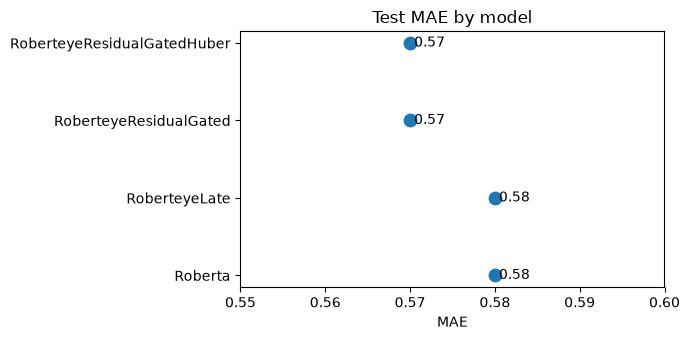

In [8]:
ru.plot_metric_points(metric_plot, "MAE")

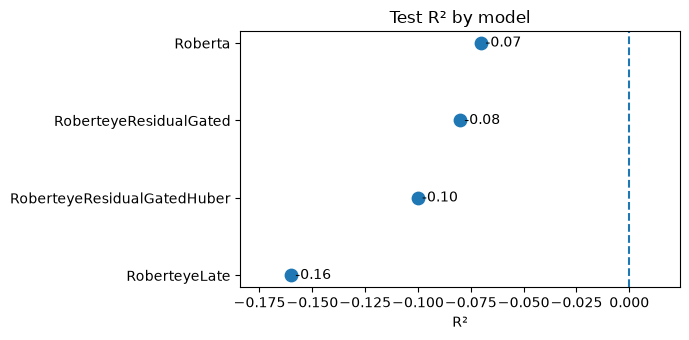

In [9]:
ru.plot_metric_points(metric_plot, "R2")

The plots show the same pattern as the table.

RMSE and MAE are error metrics, so lower values are better.

R² measures how much variation in the target is explained by the model, so higher values are better.

RoberteyeResidualGated improves over RoberteyeLate.

It remains close to the text-only Roberta baseline.

## 5. Main result

RoberteyeResidualGated improves over the late-fusion baseline, RoberteyeLate.

The improvement is small, but it is consistent across the main metrics.

The custom model performs close to the text-only Roberta baseline.

It does not clearly outperform Roberta.

This suggests that the text representation already captures much of the signal needed for subjective difficulty prediction.

## 6. Evaluation regime analysis

EyeBench evaluates the models under different generalization settings.

The regimes are:

- seen subject, unseen item
- unseen subject, seen item
- unseen subject, unseen item

This matters because the model may behave differently when it sees new texts, new readers, or both.

In [10]:
regime_columns = [
    "Seen subject unseen item",
    "Unseen subject seen item",
    "Unseen subject unseen item",
    "All",
]

In [11]:
regime_rmse = rmse[
    (rmse["Data"] == "SBSAT_STD")
    & (rmse["Eval Type"] == "test")
    & (rmse["Model"].isin(models))
][["Model"] + regime_columns].copy()

for column in regime_columns:
    regime_rmse[column] = regime_rmse[column].apply(lambda x: ru.split_metric(x)[0])

regime_rmse

,Model,Seen subject unseen item,Unseen subject seen item,Unseen subject unseen item,All
8,Roberta,0.74,0.69,0.71,0.72
9,RoberteyeLate,0.78,0.70,0.73,0.75
13,RoberteyeResidualGated,0.75,0.68,0.73,0.72
15,RoberteyeResidualGatedHuber,0.76,0.68,0.74,0.73


### 6.1 Interpretation of regime results

The regime-level results show that performance depends on the evaluation setting.

The highest RMSE appears in the seen-subject/unseen-item setting.

This suggests that predicting difficulty for new texts is difficult in this task.

`RoberteyeResidualGated` improves over RoberteyeLate in most regime-level comparisons.

However, it remains close to the text-only Roberta model.

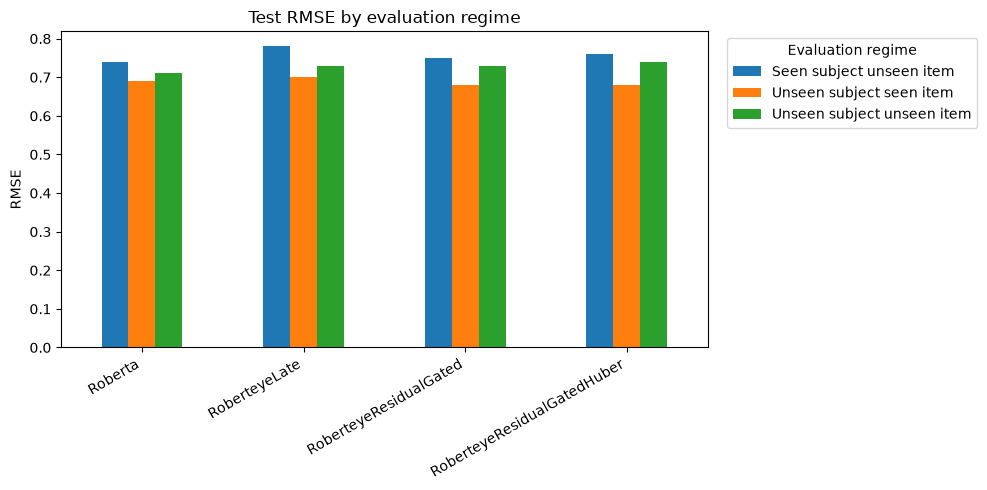

In [12]:
regime_plot = regime_rmse.set_index("Model")[
    [
        "Seen subject unseen item",
        "Unseen subject seen item",
        "Unseen subject unseen item",
    ]
]

ax = regime_plot.plot(kind="bar", figsize=(10, 5))

ax.set_ylabel("RMSE")
ax.set_xlabel("")
ax.set_title("Test RMSE by evaluation regime")
ax.legend(title="Evaluation regime", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 7. Prediction behavior of the final model

This section analyses the predictions of RoberteyeResidualGated at the trial level.

The goal is to understand how the model makes errors.

This helps explain why the model improves over late fusion but does not clearly outperform Roberta.

In [13]:
trial_paths = sorted(
    path for path in outputs_dir.rglob("trial_level_test_results.csv")
    if "RoberteyeResidualGatedArgs" in str(path)
    and "RoberteyeResidualGatedHuberArgs" not in str(path)
    and "RoberteyeResidualGatedSmallArgs" not in str(path)
    and "RoberteyeResidualGatedMediumArgs" not in str(path)
)

if len(trial_paths) == 0:
    raise FileNotFoundError(
        "No trial-level files found for RoberteyeResidualGatedArgs in outputs/."
    )

trial_results = pd.concat(
    [pd.read_csv(path) for path in trial_paths],
    ignore_index=True,
)

In [14]:
test_trials = trial_results[trial_results["eval_type"] == "test"].copy()

test_trials["error"] = test_trials["prediction_prob"] - test_trials["label"]
test_trials["absolute_error"] = test_trials["error"].abs()

In [15]:
trial_summary = pd.DataFrame(
    {
        "Number of rows": [len(trial_results)],
        "Number of test rows": [len(test_trials)],
        "Number of folds": [test_trials["fold_index"].nunique()],
        "Number of regimes": [test_trials["eval_regime"].nunique()],
    }
)

trial_summary

,Number of rows,Number of test rows,Number of folds,Number of regimes
0,1140,665,4,3


### 7.1 Prediction range

This section compares the range of true difficulty values with the range of predicted values.

This helps show whether the model uses the full target range.

In [16]:
prediction_range = pd.DataFrame(
    {
        "Value": [
            test_trials["label"].min(),
            test_trials["label"].max(),
            test_trials["label"].mean(),
            test_trials["prediction_prob"].min(),
            test_trials["prediction_prob"].max(),
            test_trials["prediction_prob"].mean(),
        ]
    },
    index=[
        "True minimum",
        "True maximum",
        "True mean",
        "Predicted minimum",
        "Predicted maximum",
        "Predicted mean",
    ],
)

prediction_range

,Value
True minimum,0.000000
True maximum,3.000000
True mean,1.276692
Predicted minimum,0.760682
Predicted maximum,1.593656
Predicted mean,1.225411


The prediction range shows that the model does not use the full target scale.

The model predicts values close to the middle of the difficulty range.

This helps explain the weak R² values.

The model reduces some errors, but it does not clearly separate low and high difficulty trials.

### 7.2 Error by true difficulty label

The error-by-label analysis shows a clear pattern.

The model overpredicts easy trials and underpredicts difficult trials.

Most predictions stay close to the middle of the scale.

This means that the model captures the general difficulty level, but it does not separate the extreme labels well.

In [17]:
error_by_label = (
    test_trials
    .groupby("label")
    .agg(
        mean_prediction=("prediction_prob", "mean"),
        mean_error=("error", "mean"),
        mean_absolute_error=("absolute_error", "mean"),
        count=("label", "count"),
    )
    .reset_index()
)

error_by_label

,label,mean_prediction,mean_error,mean_absolute_error,count
0,0.0,1.233340,1.233340,1.233340,69
1,1.0,1.223222,0.223222,0.246556,371
2,2.0,1.220201,-0.779799,0.779799,197
3,3.0,1.271526,-1.728474,1.728474,28


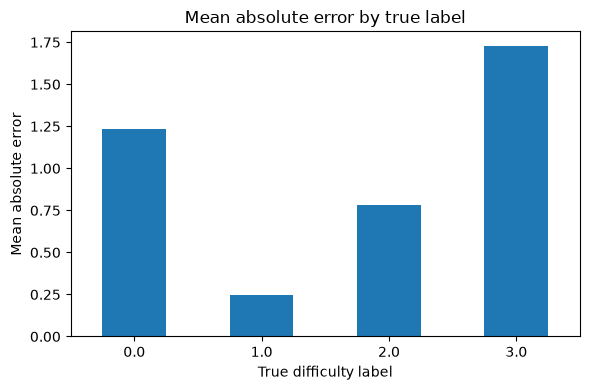

In [18]:
ax = error_by_label.plot(
    x="label",
    y="mean_absolute_error",
    kind="bar",
    legend=False,
    figsize=(6, 4),
)

ax.set_xlabel("True difficulty label")
ax.set_ylabel("Mean absolute error")
ax.set_title("Mean absolute error by true label")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The plot shows the mean absolute error for each true difficulty label.

Lower values mean that the model predicts that label more accurately.

Higher values mean that the model has more difficulty with that label.

The model performs best for label 1.

The error is larger for labels 0, 2, and 3.

This shows that the model tends to predict values near the middle of the scale.

### 7.3 Label distribution

This section checks how the true difficulty labels are distributed in the test set.

The distribution is imbalanced. Label 1 is the most common label, while labels 0 and 3 are much less frequent.

This helps explain why the model predicts values close to the middle of the scale.

In [19]:
label_distribution_test = (
    test_trials["label"]
    .value_counts()
    .sort_index()
    .rename_axis("difficulty_label")
    .reset_index(name="test_trial_count")
)

label_distribution_test

,difficulty_label,test_trial_count
0,0.0,69
1,1.0,371
2,2.0,197
3,3.0,28


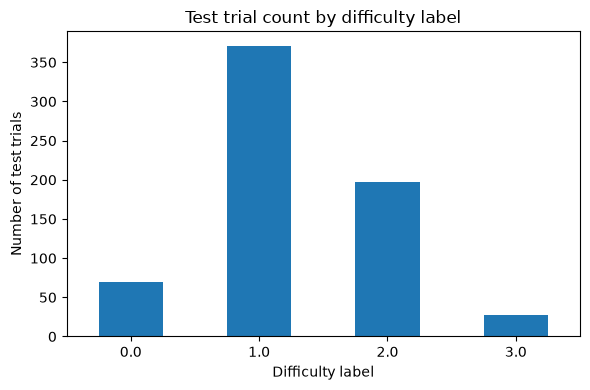

In [20]:
ax = label_distribution_test.plot(
    x="difficulty_label",
    y="test_trial_count",
    kind="bar",
    legend=False,
    figsize=(6, 4),
)

ax.set_xlabel("Difficulty label")
ax.set_ylabel("Number of test trials")
ax.set_title("Test trial count by difficulty label")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Final summary

RoberteyeResidualGated improves over the late-fusion multimodal baseline.

It performs close to the text-only Roberta baseline, but it does not clearly outperform it.

The regime-level results suggest that predicting difficulty for new texts is difficult in this task.

The trial-level analysis shows that the model predicts a narrow range of values.

The label distribution is also imbalanced, with label 1 appearing much more often than labels 0 and 3.

R² remains weak for all models because the predictions do not capture enough variation between easy and difficult trials.

The trial-level analysis shows that the final model mostly predicts values near the middle of the scale. This can keep RMSE and MAE reasonable, but it limits R² because the model does not separate low and high difficulty labels well.

Together, these results explain why the models achieve acceptable error values while still having weak R² scores.

Overall, gaze features help compared with late fusion, but they do not clearly improve over the text-only baseline in this experiment.
